[19:29:19] MRV_IMPLICIT_H SGroup on atom without aromatic bonds, 23, ignored.
[19:29:19] MRV_IMPLICIT_H SGroup on atom without aromatic bonds, 6, ignored.
[19:29:19] Explicit valence for atom # 8 N, 4, is greater than permitted
[19:29:19] ERROR: Could not sanitize molecule ending on line 1362
[19:29:19] ERROR: Explicit valence for atom # 8 N, 4, is greater than permitted
[19:29:19] Explicit valence for atom # 1 N, 4, is greater than permitted
[19:29:19] ERROR: Could not sanitize molecule ending on line 2798
[19:29:19] ERROR: Explicit valence for atom # 1 N, 4, is greater than permitted
[19:29:19] Explicit valence for atom # 1 N, 4, is greater than permitted
[19:29:19] ERROR: Could not sanitize molecule ending on line 3236
[19:29:19] ERROR: Explicit valence for atom # 1 N, 4, is greater than permitted
[19:29:19] Explicit valence for atom # 1 N, 4, is greater than permitted
[19:29:19] ERROR: Could not sanitize molecule ending on line 3648
[19:29:19] ERROR: Explicit valence for atom # 1 N

      pIC50         Source
0  5.764472  Mpro-chemic50
1  6.795880  Mpro-chemic50
2  5.826814  Mpro-chemic50
3  6.795880  Mpro-chemic50
4  6.657577  Mpro-chemic50


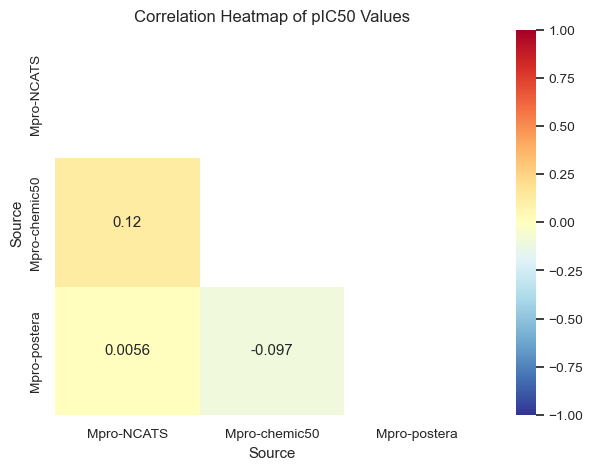

In [ ]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Style settings
sns.set_style('darkgrid')
sns.set(font_scale=0.9, rc={'figure.figsize': (12, 10)})

# Function to load SDF files and extract pIC50
def load_sdf_to_dataframe(file_path, source_name):
    pIC50_values = []
    supplier = Chem.SDMolSupplier(file_path)
    for mol in supplier:
        if mol:  # Check if the molecule is valid
            # Extract the pIC50 value (check for multiple property names)
            if mol.HasProp('pIC50'):
                pIC50 = mol.GetProp('pIC50')
            elif mol.HasProp('pIC50 (uM)'):  # Check for alternative name
                pIC50 = mol.GetProp('pIC50 (uM)')
            else:
                pIC50 = None
            pIC50_values.append(float(pIC50) if pIC50 else None)
    return pd.DataFrame({'pIC50': pIC50_values, 'Source': source_name})

# Load the three SDF files
file_paths = ['C:/Users/sabri/OneDrive/Documentos/UFG/scripts-for-analysis/input/Mpro-chemic50.sdf', 
              'C:/Users/sabri/OneDrive/Documentos/UFG/scripts-for-analysis/input/Mpro-postera.sdf', 
              'C:/Users/sabri/OneDrive/Documentos/UFG/scripts-for-analysis/input/NCATS-3CLpro.sdf']
source_names = ['Mpro-chemic50', 'Mpro-postera', 'Mpro-NCATS']

# Load all files and combine them into a single DataFrame
dfs = [load_sdf_to_dataframe(file, name) for file, name in zip(file_paths, source_names)]
df = pd.concat(dfs, ignore_index=True)

# Remove molecules without pIC50 values
df = df.dropna(subset=['pIC50'])

# Display the first rows of the DataFrame
print(df.head())

# 2. Correlate pIC50 based on the identification of each file
# Pivot the table to have pIC50 values from each source in separate columns
# Reset the index to use a proper index for pivot_table
df['Index'] = df.groupby('Source').cumcount()
pivot_table = df.pivot_table(values='pIC50', index='Index', columns='Source')

# Calculate the correlation matrix
corr = pivot_table.corr()

# Configure mask for the upper half of the correlation matrix
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True

# Plot the heatmap
with sns.axes_style("white"):
    f, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(corr, cmap='RdYlBu_r', vmin=-1, vmax=1, annot=True, mask=mask)
    plt.title('Correlation Heatmap of pIC50 Values', fontsize=12)

# Save the figure
plt.savefig('pIC50_corr.png', bbox_inches='tight', transparent=True, format='png', dpi=300)

# Display the heatmap
plt.show()

In [7]:
df

,Molecule,pIC50,Source
0,<rdkit.Chem.rdchem.Mol object at 0x00000281815...,5.764472,Mpro-chemic50
1,<rdkit.Chem.rdchem.Mol object at 0x00000281815...,6.795880,Mpro-chemic50
2,<rdkit.Chem.rdchem.Mol object at 0x00000281815...,5.826814,Mpro-chemic50
3,<rdkit.Chem.rdchem.Mol object at 0x00000281815...,6.795880,Mpro-chemic50
4,<rdkit.Chem.rdchem.Mol object at 0x00000281815...,6.657577,Mpro-chemic50
...,...,...,...
1199,<rdkit.Chem.rdchem.Mol object at 0x00000281815...,4.475996,Mpro-postera
1200,<rdkit.Chem.rdchem.Mol object at 0x00000281815...,5.642350,Mpro-postera
1201,<rdkit.Chem.rdchem.Mol object at 0x00000281815...,4.129883,Mpro-postera
1202,<rdkit.Chem.rdchem.Mol object at 0x00000281815...,6.508211,Mpro-postera
